# Support Vector Machine (SVM)

## Learning Objectives
- Understand what a **maximum-margin classifier** is and why maximising the margin leads to better generalisation
- Recognise the role of **support vectors** — the subset of training points that determine the decision boundary
- Understand the primal QP formulation and how it is converted to the **Lagrangian dual**
- Know the **KKT conditions** and how they identify support vectors
- Understand how the dual gives rise to the **kernel trick**, enabling non-linear classification without explicit feature maps

## Problem Statement

Given a training set $\{(x^{(i)}, y^{(i)})\}_{i=1}^{n}$ where $x^{(i)} \in \mathbb{R}^{d}$ and $y^{(i)} \in \{-1, +1\}$, find parameters $(w, b)$ that define a separating hyperplane

$$\{x : w^T x + b = 0\}, \quad w \in \mathbb{R}^d,\; b \in \mathbb{R}$$

such that the **geometric margin** is maximised:

$$\displaystyle (w^*, b^*) = \arg\max_{w,\, b} \; \frac{2}{\|w\|} \quad \text{subject to} \quad y^{(i)}(w^T x^{(i)} + b) \geq 1, \quad \forall\, i$$

---

### Geometric Intuition

A linear classifier assigns labels by the sign of $w^T x + b$.  Many separating hyperplanes may exist — SVM selects the one that maximises the **margin**: the perpendicular distance between the hyperplane and the nearest training points on each side.

| Quantity | Definition |
|---|---|
| Decision hyperplane | $w^T x + b = 0$ |
| Positive margin boundary | $w^T x + b = +1$ |
| Negative margin boundary | $w^T x + b = -1$ |
| Geometric margin | $\dfrac{2}{\|w\|}$ — width between the two margin boundaries |
| Support vectors | Training points satisfying $y^{(i)}(w^T x^{(i)} + b) = 1$ — lie exactly on the margin boundaries |

---

### Why Maximise Margin?

A large margin means the classifier is far from every training point, giving it more "room for error." By the VC-dimension / PAC learning theory, a larger margin directly bounds the generalisation error — the classifier is less likely to overfit even in high dimensions.

---

### Equivalent Primal QP

Maximising $\frac{2}{\|w\|}$ is equivalent to minimising $\frac{1}{2}\|w\|^2$:

$$\displaystyle \min_{w,\, b} \; \frac{1}{2}\|w\|^2 \quad \text{subject to} \quad y^{(i)}(w^T x^{(i)} + b) \geq 1, \quad i = 1, \ldots, n$$

This is a **convex quadratic program** with $n$ linear constraints — it has a unique global optimum.

## High-Level Derivation Steps

> Full derivations are in separate notebooks. This cell maps the logical flow so each step can be studied in isolation.

---

### Step 1 — Define Functional and Geometric Margin

- **Functional margin** of a point: $\hat{\gamma}^{(i)} = y^{(i)}(w^T x^{(i)} + b)$ — a signed distance that is positive iff the point is correctly classified
- **Geometric margin**: normalise by $\|w\|$ to get a scale-invariant distance: $\gamma^{(i)} = \dfrac{\hat{\gamma}^{(i)}}{\|w\|}$
- Fix the scaling ambiguity by requiring $\min_i \hat{\gamma}^{(i)} = 1$ (canonical form)

---

### Step 2 — Formulate the Primal QP

- The goal is $\max \dfrac{1}{\|w\|}$ subject to the margin constraints — rewrite as $\min \dfrac{1}{2}\|w\|^2$
- This is a **convex QP** in $(w, b)$ with $n$ linear inequality constraints

---

### Step 3 — Construct the Lagrangian

- Introduce one Lagrange multiplier $\alpha_i \geq 0$ per constraint (one per training example)
- Form: $\mathcal{L}(w, b, \alpha) = \dfrac{1}{2}\|w\|^2 - \displaystyle\sum_{i=1}^n \alpha_i \left[y^{(i)}(w^T x^{(i)} + b) - 1\right]$

---

### Step 4 — Derive the Dual via KKT Stationarity

- Set $\nabla_w \mathcal{L} = 0$ → express $w$ in terms of $\alpha$: $w = \displaystyle\sum_i \alpha_i y^{(i)} x^{(i)}$
- Set $\partial \mathcal{L}/\partial b = 0$ → constraint: $\displaystyle\sum_i \alpha_i y^{(i)} = 0$
- Substitute back to eliminate $w$ and $b$, obtaining the **Lagrangian dual**

---

### Step 5 — Solve the Dual QP

- The dual is: $\max_\alpha \displaystyle\sum_i \alpha_i - \dfrac{1}{2}\displaystyle\sum_{i,j} \alpha_i \alpha_j y^{(i)} y^{(j)} \langle x^{(i)}, x^{(j)} \rangle$, subject to $\alpha_i \geq 0$, $\displaystyle\sum_i \alpha_i y^{(i)} = 0$
- The dual depends on inputs **only through inner products** $\langle x^{(i)}, x^{(j)} \rangle$ — this is what enables the kernel trick

---

### Step 6 — Apply KKT Complementarity to Find Support Vectors

- KKT complementarity: $\alpha_i \left[y^{(i)}(w^T x^{(i)} + b) - 1\right] = 0$ for all $i$
- Either $\alpha_i = 0$ (point does not contribute to $w$) or the point lies exactly on the margin boundary (a **support vector**)
- Only support vectors have $\alpha_i > 0$; all other training points are irrelevant at test time

---

### Step 7 — Recover $w$, $b$ and Predict

- $w = \displaystyle\sum_{i \in \text{SV}} \alpha_i y^{(i)} x^{(i)}$
- $b$ recovered from any support vector: $b = y^{(i)} - w^T x^{(i)}$ (average over all SVs for numerical stability)
- Prediction: $\hat{y} = \text{sign}(w^T x + b)$

---

### Step 8 — Extend to Non-Linear Boundaries via the Kernel Trick

- Replace every inner product $\langle x^{(i)}, x^{(j)} \rangle$ with a kernel $K(x^{(i)}, x^{(j)}) = \langle \phi(x^{(i)}), \phi(x^{(j)}) \rangle$
- The kernel computes the inner product in a (possibly infinite-dimensional) feature space $\phi$ **without explicitly mapping** the data
- Common kernels: polynomial $(\gamma x^T z + r)^p$, RBF $\exp(-\gamma\|x-z\|^2)$, sigmoid

## Derivation

### Step 1 — Functional and Geometric Margin

The **functional margin** of the $i$-th training example with respect to $(w, b)$ is:

$$\hat{\gamma}^{(i)} = y^{(i)}\bigl(w^T x^{(i)} + b\bigr)$$

A positive functional margin means the point is correctly classified; its magnitude reflects confidence.

The **geometric margin** normalises by $\|w\|$ to remove dependence on the scale of $w$:

$$\gamma^{(i)} = \frac{y^{(i)}\bigl(w^T x^{(i)} + b\bigr)}{\|w\|} = \frac{\hat{\gamma}^{(i)}}{\|w\|}$$

**Scale invariance:** Replacing $(w, b)$ with $(cw, cb)$ for any $c > 0$ leaves the decision boundary $w^T x + b = 0$ unchanged but scales $\hat{\gamma}^{(i)}$ by $c$. The geometric margin $\gamma^{(i)}$ is unaffected.

**Canonical (unit) form:** Exploiting scale freedom, we impose

$$\min_i \hat{\gamma}^{(i)} = 1 \quad \Longleftrightarrow \quad \min_i \, y^{(i)}\bigl(w^T x^{(i)} + b\bigr) = 1$$

Under this convention the closest training point has geometric margin $\tfrac{1}{\|w\|}$, so the total **margin width** — the gap between the two margin hyperplanes — is:

$$\frac{2}{\|w\|}$$

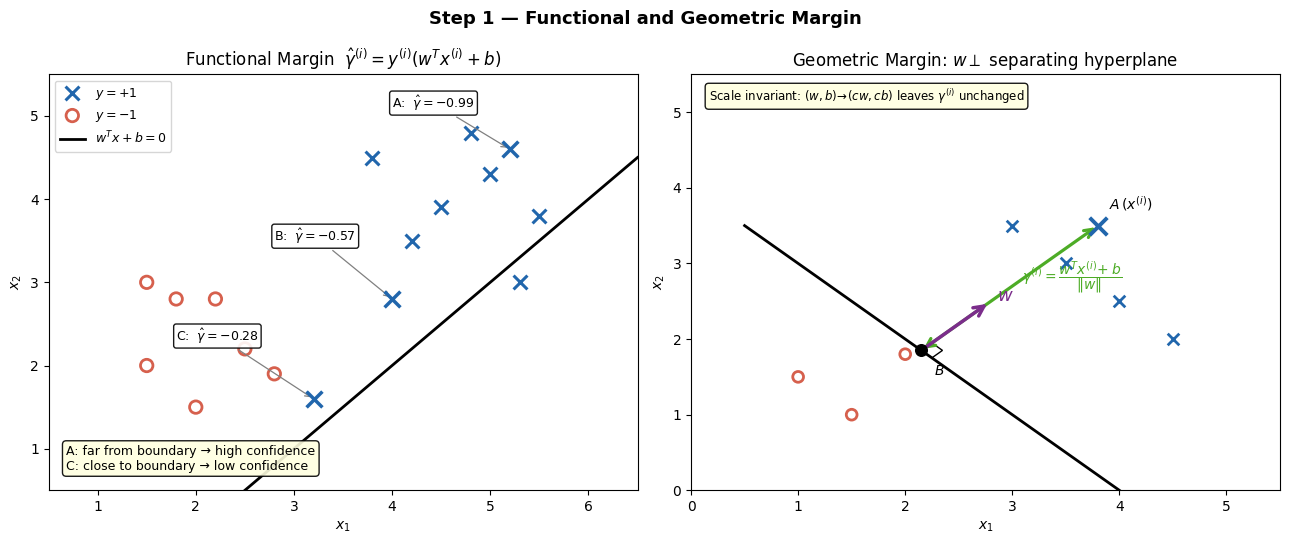

In [1]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ─── Left: functional margin intuition (CS229 §1 figure) ─────────────────
ax = axes[0]
pos = np.array([[3.8,4.5],[4.5,3.9],[5.0,4.3],[4.2,3.5],[5.3,3.0],[4.8,4.8],[5.5,3.8]])
neg = np.array([[1.5,2.0],[2.0,1.5],[2.5,2.2],[1.8,2.8],[2.8,1.9],[1.5,3.0],[2.2,2.8]])
ax.scatter(pos[:,0], pos[:,1], marker='x', s=100, c='#2166ac', linewidths=2.2, label='$y=+1$')
ax.scatter(neg[:,0], neg[:,1], marker='o', s=80, facecolors='none',
           edgecolors='#d6604d', linewidths=2, label='$y=-1$')

# boundary: x₂ = x₁ − 2,  i.e. w=[1,−1]/√2, b=−2/√2
w = np.array([1., -1.]) / np.sqrt(2)
b = -2. / np.sqrt(2)
xr = np.linspace(0.5, 6.5, 200)
ax.plot(xr, xr - 2, 'k-', lw=2, label='$w^Tx + b = 0$')

for pt, nm, tx, ty in [
    (np.array([5.2, 4.6]), 'A', 4.0, 5.1),
    (np.array([4.0, 2.8]), 'B', 2.8, 3.5),
    (np.array([3.2, 1.6]), 'C', 1.8, 2.3),
]:
    fm = w @ pt + b
    ax.scatter(*pt, marker='x', s=130, c='#2166ac', linewidths=2.5, zorder=6)
    ax.annotate(f'{nm}:  $\\hat{{\\gamma}}={fm:.2f}$', pt, xytext=(tx, ty), fontsize=9,
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.9),
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.9))

ax.set_xlim(0.5, 6.5); ax.set_ylim(0.5, 5.5)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Functional Margin  $\\hat{\\gamma}^{(i)} = y^{(i)}(w^Tx^{(i)}+b)$')
ax.legend(fontsize=9, loc='upper left')
ax.text(0.03, 0.05, 'A: far from boundary → high confidence\nC: close to boundary → low confidence',
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))

# ─── Right: geometric margin diagram (CS229 §3 figure) ───────────────────
ax = axes[1]
w2 = np.array([1., 1.])
b2 = -4.0
wn = w2 / np.linalg.norm(w2)

ax.plot(xr, 4 - xr, 'k-', lw=2)
pos2 = np.array([[3.5,3.0],[4.0,2.5],[3.0,3.5],[4.5,2.0]])
neg2 = np.array([[1.0,1.5],[1.5,1.0],[2.0,1.8]])
ax.scatter(pos2[:,0], pos2[:,1], marker='x', s=70, c='#2166ac', linewidths=2)
ax.scatter(neg2[:,0], neg2[:,1], marker='o', s=60,
           facecolors='none', edgecolors='#d6604d', linewidths=2)

A2 = np.array([3.8, 3.5])
gamma_A = (w2 @ A2 + b2) / np.linalg.norm(w2)
B2 = A2 - gamma_A * wn          # foot of perpendicular on boundary

ax.scatter(*A2, marker='x', s=160, c='#2166ac', linewidths=2.8, zorder=7)
ax.scatter(*B2, s=70, c='k', zorder=7)
ax.annotate('$A\\,(x^{(i)})$', A2, xytext=(A2[0]+0.1, A2[1]+0.22), fontsize=10)
ax.annotate('$B$',             B2, xytext=(B2[0]+0.12, B2[1]-0.32), fontsize=10)

# γ double-headed arrow A→B
ax.annotate('', xytext=A2, xy=B2,
            arrowprops=dict(arrowstyle='<->', color='#4dac26', lw=2.3, mutation_scale=15))
mid = (A2 + B2) / 2
ax.text(mid[0]+0.12, mid[1]+0.08,
        r'$\gamma^{(i)} = \dfrac{w^Tx^{(i)}\!+b}{\|w\|}$', fontsize=10, color='#4dac26')

# w arrow at B
ax.annotate('', xytext=B2, xy=B2 + 0.9*wn,
            arrowprops=dict(arrowstyle='->', color='#7b2d8b', lw=2.5, mutation_scale=18))
ax.text(B2[0]+0.9*wn[0]+0.07, B2[1]+0.9*wn[1]+0.02,
        r'$w$', fontsize=13, color='#7b2d8b', fontweight='bold')

# right-angle mark at B
t = np.array([wn[1], -wn[0]])
s = 0.14
sq = np.array([B2, B2+s*t, B2+s*t+s*wn, B2+s*wn])
ax.add_patch(plt.Polygon(sq, fill=False, edgecolor='k', lw=1))

ax.set_xlim(0, 5.5); ax.set_ylim(0, 5.5)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title(r'Geometric Margin: $w \perp$ separating hyperplane')
ax.text(0.03, 0.97, r'Scale invariant: $(w,b)\!\to\!(cw,cb)$ leaves $\gamma^{(i)}$ unchanged',
        transform=ax.transAxes, fontsize=8.5, va='top',
        bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))

fig.suptitle('Step 1 — Functional and Geometric Margin', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 2 — Primal QP

We want to find the hyperplane that maximises the margin. Under the canonical form the problem is:

$$\max_{w,\,b} \;\frac{2}{\|w\|} \quad \text{s.t.} \quad y^{(i)}\bigl(w^T x^{(i)} + b\bigr) \geq 1, \quad i = 1,\ldots,n$$

Maximising $\tfrac{2}{\|w\|}$ is equivalent to minimising $\|w\|$, which is equivalent to minimising $\tfrac{1}{2}\|w\|^2$ (the factor $\tfrac{1}{2}$ is introduced for convenience when differentiating). The primal QP is:

$$\boxed{\min_{w,\,b} \;\frac{1}{2}\|w\|^2 \quad \text{s.t.} \quad y^{(i)}\bigl(w^T x^{(i)} + b\bigr) \geq 1, \quad i = 1,\ldots,n}$$

The objective is **strictly convex quadratic** and the $n$ constraints are linear, so this QP has a unique global optimum and can be solved efficiently.

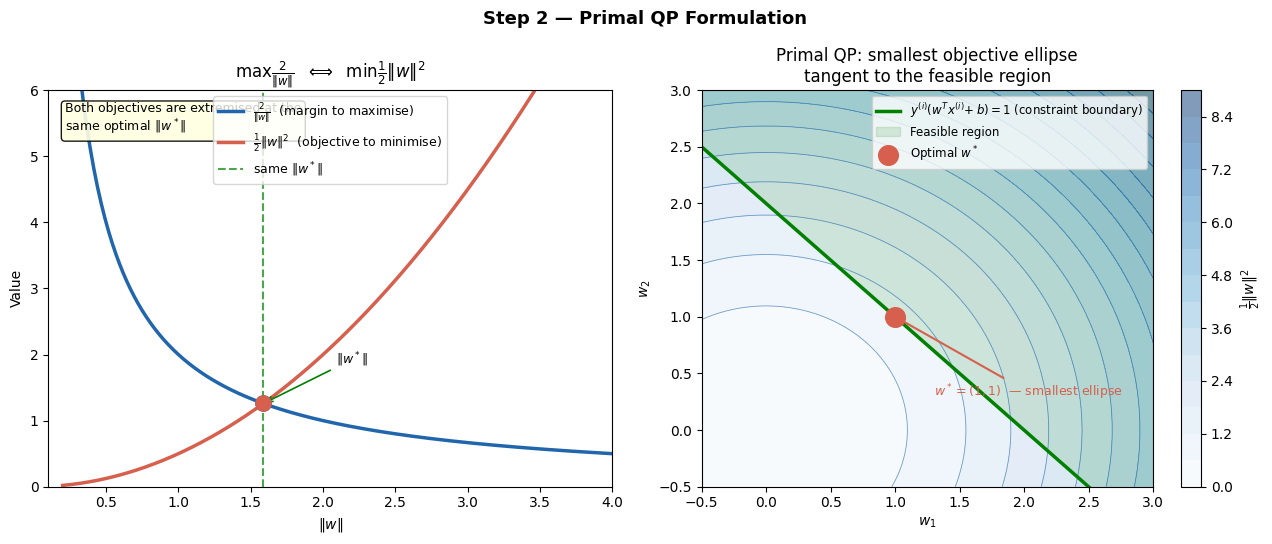

In [2]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ─── Left: max 2/‖w‖ ≡ min ½‖w‖² (objective equivalence) ────────────────
ax = axes[0]
nw = np.linspace(0.2, 4.0, 300)
ax.plot(nw, 2/nw,       color='#2166ac', lw=2.5, label=r'$\frac{2}{\|w\|}$  (margin to maximise)')
ax.plot(nw, 0.5*nw**2,  color='#d6604d', lw=2.5, label=r'$\frac{1}{2}\|w\|^2$  (objective to minimise)')

# Both objectives optimised at the same ‖w*‖
opt = 1.587   # (2)^(1/3) — where 2/nw and nw²/2 share the same derivative sign-flip
ax.axvline(opt, color='green', lw=1.5, ls='--', alpha=0.7, label=r'same $\|w^*\|$')
ax.scatter([opt], [2/opt],      s=120, c='#2166ac', zorder=6)
ax.scatter([opt], [0.5*opt**2], s=120, c='#d6604d', zorder=6)
ax.annotate(r'$\|w^*\|$', (opt, 0.5*opt**2), xytext=(opt+0.5, 0.5*opt**2+0.6),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='green', lw=1.2))

ax.set_xlabel(r'$\|w\|$'); ax.set_ylabel('Value')
ax.set_title(r'$\max \frac{2}{\|w\|}$  $\Longleftrightarrow$  $\min \frac{1}{2}\|w\|^2$')
ax.legend(fontsize=9); ax.set_ylim(0, 6); ax.set_xlim(0.1, 4)
ax.text(0.03, 0.97, 'Both objectives are extremised at the\nsame optimal $\\|w^*\\|$',
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))

# ─── Right: 2D QP — objective contours + feasible half-plane ─────────────
ax = axes[1]

# Simple 1-constraint illustration in (w₁, w₂) space:
# constraint: w₁ + w₂ ≥ 2  (represents one canonical margin constraint)
w1v = np.linspace(-0.5, 3.0, 300)
w2v = np.linspace(-0.5, 3.0, 300)
W1, W2 = np.meshgrid(w1v, w2v)
Obj = 0.5*(W1**2 + W2**2)

# Feasible region: W1 + W2 >= 2
feasible = (W1 + W2 >= 2)
Obj_masked = np.where(feasible, Obj, np.nan)

cs = ax.contourf(W1, W2, Obj, levels=15, cmap='Blues', alpha=0.5)
ax.contour(W1, W2, Obj, levels=15, colors='#2166ac', linewidths=0.6, alpha=0.6)
plt.colorbar(cs, ax=ax, label=r'$\frac{1}{2}\|w\|^2$')

# Feasible boundary: w1 + w2 = 2
x_bnd = np.linspace(-0.5, 3.0, 200)
ax.plot(x_bnd, 2 - x_bnd, 'g-', lw=2.5, label=r'$y^{(i)}(w^Tx^{(i)}\!+b)=1$ (constraint boundary)')
ax.fill_between(x_bnd, 2 - x_bnd, 3.0, alpha=0.12, color='green', label='Feasible region')

# Optimal point: closest point on w1+w2=2 to origin → w1=w2=1
ax.scatter([1.0], [1.0], s=200, c='#d6604d', zorder=6, label='Optimal $w^*$')
ax.annotate(r'$w^* = (1,1)$  — smallest ellipse', (1.0, 1.0),
            xytext=(1.3, 0.3), fontsize=9, color='#d6604d',
            arrowprops=dict(arrowstyle='->', color='#d6604d', lw=1.5))

ax.set_xlim(-0.5, 3.0); ax.set_ylim(-0.5, 3.0)
ax.set_xlabel('$w_1$'); ax.set_ylabel('$w_2$')
ax.set_title('Primal QP: smallest objective ellipse\ntangent to the feasible region')
ax.legend(fontsize=8.5, loc='upper right')

fig.suptitle('Step 2 — Primal QP Formulation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 3 — Constructing the Lagrangian

Rewrite each inequality constraint as $g_i(w,b) \leq 0$ where $g_i = 1 - y^{(i)}(w^T x^{(i)} + b)$.

Introduce one Lagrange multiplier $\alpha_i \geq 0$ per constraint. The **generalised Lagrangian** is:

$$\mathcal{L}(w, b, \alpha) = \frac{1}{2}\|w\|^2 - \sum_{i=1}^{n} \alpha_i \Bigl[y^{(i)}\bigl(w^T x^{(i)} + b\bigr) - 1\Bigr]$$

**Why this form?** For any fixed $(w, b)$:

$$\max_{\alpha \geq 0} \mathcal{L}(w, b, \alpha) = \begin{cases} \frac{1}{2}\|w\|^2 & \text{if all constraints satisfied} \\ +\infty & \text{otherwise} \end{cases}$$

So $\min_{w,b} \max_{\alpha \geq 0} \mathcal{L} = \min_{w,b} \tfrac{1}{2}\|w\|^2$ subject to the constraints — the primal problem.

**Strong duality:** The primal is a convex QP with linear constraints. Slater's condition (the existence of a strictly feasible point, satisfied when the data is linearly separable) guarantees that:

$$\min_{w,b} \max_{\alpha \geq 0} \mathcal{L}(w, b, \alpha) = \max_{\alpha \geq 0} \min_{w,b} \mathcal{L}(w, b, \alpha)$$

We can therefore solve the **dual** problem instead of the primal.

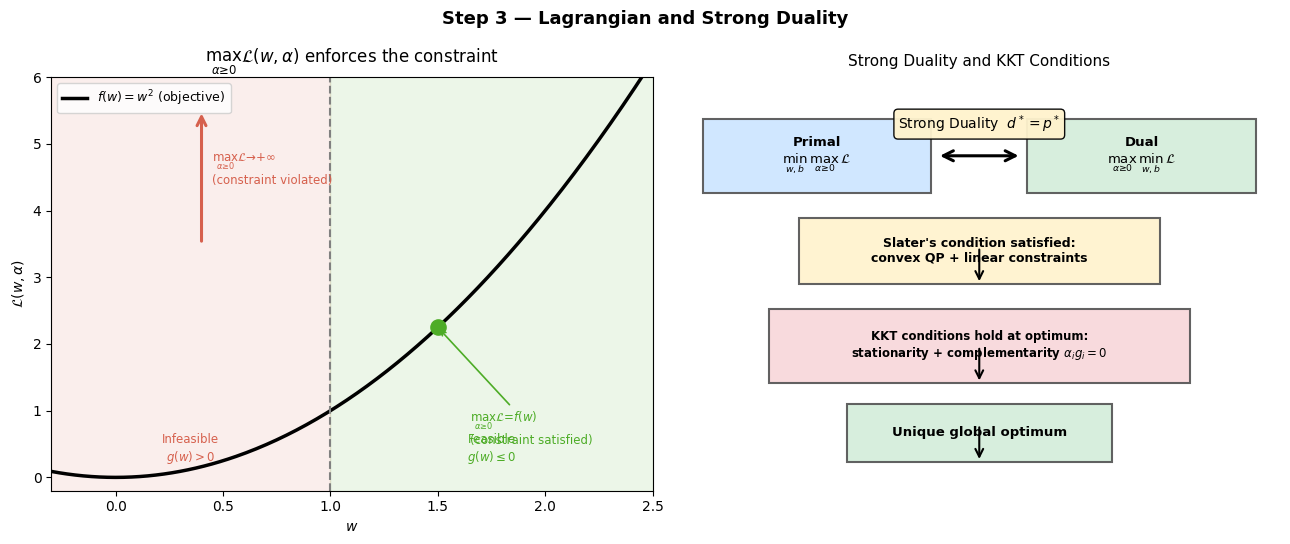

In [3]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ─── Left: max_α L acts as an "infinity barrier" ─────────────────────────
# 1-D toy: min w², s.t. g(w) = 1 − w ≤ 0  (feasible: w ≥ 1)
# L(w,α) = w² − α(w − 1)
# max_{α≥0} L = w²  if w≥1  (set α=0);  +∞  if w<1  (α→+∞)
ax = axes[0]
w_vals = np.linspace(-0.3, 2.5, 300)

ax.plot(w_vals, w_vals**2, 'k-', lw=2.5, label=r'$f(w)=w^2$ (objective)')
ax.fill_betweenx([-0.2, 6.5], -0.3, 1.0, alpha=0.10, color='#d6604d')
ax.fill_betweenx([-0.2, 6.5],  1.0, 2.5, alpha=0.10, color='#4dac26')
ax.axvline(1.0, color='gray', lw=1.5, ls='--')

# Infeasible arrow (L→+∞)
ax.annotate('', xytext=(0.4, 3.5), xy=(0.4, 5.5),
            arrowprops=dict(arrowstyle='->', color='#d6604d', lw=2.2, mutation_scale=16))
ax.text(0.45, 4.4, r'$\max_{\alpha\geq0}\mathcal{L}\to+\infty$' + '\n(constraint violated)',
        fontsize=8.5, color='#d6604d')

# Feasible label
ax.scatter([1.5], [1.5**2], s=120, c='#4dac26', zorder=5)
ax.annotate(r'$\max_{\alpha\geq0}\mathcal{L} = f(w)$' + '\n(constraint satisfied)',
            (1.5, 1.5**2), xytext=(1.65, 0.5), fontsize=8.5, color='#4dac26',
            arrowprops=dict(arrowstyle='->', color='#4dac26', lw=1.2))

ax.text(0.35, 0.25, 'Infeasible\n$g(w)>0$', fontsize=8.5, color='#d6604d', ha='center')
ax.text(1.75, 0.25, 'Feasible\n$g(w)\\leq 0$', fontsize=8.5, color='#4dac26', ha='center')

ax.set_xlabel('$w$'); ax.set_ylabel(r'$\mathcal{L}(w,\alpha)$')
ax.set_title(r'$\max_{\alpha\geq0}\mathcal{L}(w,\alpha)$ enforces the constraint')
ax.set_xlim(-0.3, 2.5); ax.set_ylim(-0.2, 6.0)
ax.legend(fontsize=9)

# ─── Right: strong duality d* = p* — diagram ─────────────────────────────
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')

def panel(ax, x, y, w, h, fc, text, fs=9.5):
    ax.add_patch(plt.Rectangle((x, y), w, h, fc=fc, ec='#555', lw=1.5, alpha=0.92))
    ax.text(x+w/2, y+h/2, text, ha='center', va='center', fontsize=fs, fontweight='bold')

panel(ax, 0.4, 7.2, 3.8, 1.8, '#cce5ff',
      'Primal\n' + r'$\min_{w,b}\,\max_{\alpha\geq0}\,\mathcal{L}$')
panel(ax, 5.8, 7.2, 3.8, 1.8, '#d4edda',
      'Dual\n' + r'$\max_{\alpha\geq0}\,\min_{w,b}\,\mathcal{L}$')

ax.annotate('', xy=(5.7, 8.1), xytext=(4.3, 8.1),
            arrowprops=dict(arrowstyle='<->', color='k', lw=2.2, mutation_scale=18))
ax.text(5.0, 8.75, 'Strong Duality  $d^* = p^*$', ha='center', fontsize=10,
        bbox=dict(boxstyle='round', fc='#fff3cd', alpha=0.95))

panel(ax, 2.0, 5.0, 6.0, 1.6, '#fff3cd',
      "Slater's condition satisfied:\nconvex QP + linear constraints", fs=9)
ax.annotate('', xy=(5.0, 5.0), xytext=(5.0, 5.9),
            arrowprops=dict(arrowstyle='->', color='k', lw=1.5, mutation_scale=14))

panel(ax, 1.5, 2.6, 7.0, 1.8, '#f8d7da',
      'KKT conditions hold at optimum:\n'
      r'stationarity + complementarity $\alpha_i g_i = 0$', fs=8.5)
ax.annotate('', xy=(5.0, 2.6), xytext=(5.0, 3.5),
            arrowprops=dict(arrowstyle='->', color='k', lw=1.5, mutation_scale=14))

panel(ax, 2.8, 0.7, 4.4, 1.4, '#d4edda', 'Unique global optimum', fs=9.5)
ax.annotate('', xy=(5.0, 0.7), xytext=(5.0, 1.6),
            arrowprops=dict(arrowstyle='->', color='k', lw=1.5, mutation_scale=14))

ax.set_title('Strong Duality and KKT Conditions', fontsize=11, pad=8)

fig.suptitle('Step 3 — Lagrangian and Strong Duality', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 4 — KKT Stationarity Conditions

To compute $\min_{w,b} \mathcal{L}(w, b, \alpha)$ for fixed $\alpha$, set the partial derivatives to zero.

**Gradient with respect to $w$:**

$$\nabla_w \mathcal{L} = w - \sum_{i=1}^{n} \alpha_i y^{(i)} x^{(i)} = 0$$

$$\therefore \quad \boxed{w = \sum_{i=1}^{n} \alpha_i y^{(i)} x^{(i)}}$$

The optimal $w$ is a weighted sum of training inputs — only examples with $\alpha_i > 0$ contribute.

**Partial derivative with respect to $b$:**

$$\frac{\partial \mathcal{L}}{\partial b} = -\sum_{i=1}^{n} \alpha_i y^{(i)} = 0$$

$$\therefore \quad \boxed{\sum_{i=1}^{n} \alpha_i y^{(i)} = 0}$$

This is an equality constraint on the dual variables. These two conditions are then substituted back into $\mathcal{L}$ to eliminate $w$ and $b$.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Minimal linearly-separable dataset (chosen so SVs are visible)
np.random.seed(0)
X = np.array([[1.0, 1.5], [1.5, 2.5], [2.0, 1.0],    # y = +1
              [3.5, 3.5], [4.0, 2.5], [4.5, 4.0],    # y = -1
              [3.0, 4.5], [2.5, 4.0]])
y = np.array([1, 1, 1, -1, -1, -1, -1, -1])

# Fit SVM (via sklearn under the hood for correctness)
from sklearn.svm import SVC
clf = SVC(kernel='linear', C=1e6)
clf.fit(X, y)
w_fit   = clf.coef_[0]
b_fit   = clf.intercept_[0]
sv_idx  = clf.support_
alphas  = np.abs(clf.dual_coef_[0])   # |α_i y_i| = α_i

# ─── Left: w* as weighted sum of SV contributions ────────────────────────
ax = axes[0]

xmin, xmax = X[:,0].min()-0.5, X[:,0].max()+0.8
ymin, ymax = X[:,1].min()-0.5, X[:,1].max()+0.8
xr = np.linspace(xmin, xmax, 200)

db   = -(w_fit[0]*xr + b_fit)         / w_fit[1]
m_p  = -(w_fit[0]*xr + b_fit - 1)    / w_fit[1]
m_n  = -(w_fit[0]*xr + b_fit + 1)    / w_fit[1]
ax.plot(xr, db,  'k-',  lw=2)
ax.plot(xr, m_p, 'k--', lw=1.5)
ax.plot(xr, m_n, 'k--', lw=1.5)

ax.scatter(X[y==1,0],  X[y==1,1],  marker='x', s=90,  c='#2166ac', linewidths=2.2, label='$y=+1$')
ax.scatter(X[y==-1,0], X[y==-1,1], marker='o', s=70,  facecolors='none', edgecolors='#d6604d', linewidths=2, label='$y=-1$')

# Highlight SVs and draw α_i y_i x^(i) contribution arrows from SV toward w direction
wn = w_fit / np.linalg.norm(w_fit)
for k, (si, a) in enumerate(zip(sv_idx, alphas)):
    ax.scatter(X[si,0], X[si,1], s=250, facecolors='none', edgecolors='#4dac26', linewidths=2.5, zorder=5)
    sign = int(y[si])
    ax.annotate('', xytext=X[si], xy=X[si] + 0.35*sign*wn,
                arrowprops=dict(arrowstyle='->', color='#7b2d8b', lw=1.8, mutation_scale=13))
    ax.text(X[si,0]+0.07, X[si,1]-0.28, f'$\\alpha_{k+1}={a:.2f}$', fontsize=7.5, color='#7b2d8b')

# w* arrow at center
cx = np.mean(X, axis=0)
ax.annotate('', xytext=cx, xy=cx + 0.7*wn,
            arrowprops=dict(arrowstyle='->', color='#7b2d8b', lw=3, mutation_scale=20))
ax.text(cx[0]+0.7*wn[0]+0.05, cx[1]+0.7*wn[1]+0.05,
        r'$w^*$', fontsize=12, color='#7b2d8b', fontweight='bold')

ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title(r'$w^* = \sum_{i \in \mathrm{SV}} \alpha_i y^{(i)} x^{(i)}$' +
             '\nPurple arrows: per-SV contribution direction')
ax.legend(fontsize=9)

# ─── Right: the two stationarity conditions as a derivation panel ─────────
ax = axes[1]
ax.axis('off')
ax.set_xlim(0,10); ax.set_ylim(0,10)

def row(ax, y0, h, fc, txt, fs=10):
    ax.add_patch(plt.Rectangle((0.5, y0), 9.0, h, fc=fc, ec='#888', lw=1.2, alpha=0.9))
    ax.text(5.0, y0+h/2, txt, ha='center', va='center', fontsize=fs)

row(ax, 8.2, 1.4, '#cce5ff', r'$\nabla_w\,\mathcal{L} = w - \sum_i \alpha_i y^{(i)} x^{(i)} = 0$', 11)
ax.text(5, 7.7, r'$\Downarrow$', ha='center', va='center', fontsize=18)
row(ax, 6.3, 1.2, '#d4edda', r'$w^* = \displaystyle\sum_{i=1}^n \alpha_i\,y^{(i)}\,x^{(i)}$', 12)
row(ax, 4.9, 1.1, '#fff3cd',
    r'Only SVs $(\alpha_i>0)$ contribute — sparse representation', 9)

ax.text(5, 4.4, r'$\Downarrow$', ha='center', va='center', fontsize=18, color='gray')

row(ax, 2.9, 1.4, '#cce5ff', r'$\dfrac{\partial\mathcal{L}}{\partial b} = -\sum_i \alpha_i y^{(i)} = 0$', 11)
ax.text(5, 2.4, r'$\Downarrow$', ha='center', va='center', fontsize=18)
row(ax, 0.8, 1.3, '#d4edda',
    r'$\sum_{i=1}^n \alpha_i\,y^{(i)} = 0$   (dual equality constraint)', 10)

ax.set_title('KKT Stationarity: Eliminating $w$ and $b$', fontsize=11, pad=8)

fig.suptitle('Step 4 — KKT Stationarity Conditions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

ValueError: 
w^* = \displaystyle\sum_{i=1}^n \alpha_i\,y^{(i)}\,x^{(i)}
      ^
ParseFatalException: Unknown symbol: \displaystyle, found '\'  (at char 6), (line:1, col:7)

Error in callback <function _draw_all_if_interactive at 0x73d6ccb6a3b0> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
w^* = \displaystyle\sum_{i=1}^n \alpha_i\,y^{(i)}\,x^{(i)}
      ^
ParseFatalException: Unknown symbol: \displaystyle, found '\'  (at char 6), (line:1, col:7)

ValueError: 
w^* = \displaystyle\sum_{i=1}^n \alpha_i\,y^{(i)}\,x^{(i)}
      ^
ParseFatalException: Unknown symbol: \displaystyle, found '\'  (at char 6), (line:1, col:7)

<Figure size 1300x550 with 2 Axes>

### Step 5 — Deriving the Lagrangian Dual

Substitute $w = \sum_i \alpha_i y^{(i)} x^{(i)}$ and $\sum_i \alpha_i y^{(i)} = 0$ back into $\mathcal{L}$.

**Expand $\tfrac{1}{2}\|w\|^2$:**

$$\frac{1}{2}\|w\|^2 = \frac{1}{2} w^T w = \frac{1}{2}\sum_{i=1}^n\sum_{j=1}^n \alpha_i \alpha_j y^{(i)} y^{(j)} \langle x^{(i)}, x^{(j)} \rangle$$

**Expand the sum term:**

$$\sum_{i=1}^n \alpha_i y^{(i)} w^T x^{(i)} = \sum_{i=1}^n \alpha_i y^{(i)} \Biggl(\sum_{j=1}^n \alpha_j y^{(j)} x^{(j)}\Biggr)^{\!T} x^{(i)} = \sum_{i=1}^n\sum_{j=1}^n \alpha_i \alpha_j y^{(i)} y^{(j)} \langle x^{(j)}, x^{(i)} \rangle$$

**The $b$ term vanishes** because $\sum_i \alpha_i y^{(i)} = 0$:

$$-b\sum_{i=1}^n \alpha_i y^{(i)} = 0$$

**Combining:**

$$\mathcal{L} = \frac{1}{2}\sum_{i,j} \alpha_i \alpha_j y^{(i)} y^{(j)} \langle x^{(i)}, x^{(j)} \rangle \;-\; \sum_{i,j} \alpha_i \alpha_j y^{(i)} y^{(j)} \langle x^{(i)}, x^{(j)} \rangle \;+\; \sum_{i=1}^n \alpha_i$$

$$= \sum_{i=1}^n \alpha_i - \frac{1}{2}\sum_{i=1}^n\sum_{j=1}^n \alpha_i \alpha_j y^{(i)} y^{(j)} \langle x^{(i)}, x^{(j)} \rangle$$

This is the **Lagrangian dual objective** $g(\alpha)$. The dual problem is:

$$\boxed{\max_{\alpha} \;\sum_{i=1}^n \alpha_i - \frac{1}{2}\sum_{i=1}^n\sum_{j=1}^n \alpha_i \alpha_j y^{(i)} y^{(j)} \langle x^{(i)}, x^{(j)} \rangle \quad \text{s.t.} \quad \alpha_i \geq 0,\; \sum_{i=1}^n \alpha_i y^{(i)} = 0}$$

The dual is a **concave QP** in $\alpha$ with $n$ non-negativity constraints and one linear equality. Crucially, inputs appear **only through inner products** $\langle x^{(i)}, x^{(j)} \rangle$ — this enables the kernel trick.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Two-point example: x⁽¹⁾=[1,0] y⁽¹⁾=+1,  x⁽²⁾=[-1,0] y⁽²⁾=-1
# W(α₁,α₂) = α₁+α₂ − ½(α₁²·1 + 2α₁α₂·(+1)(−1)(−1) + α₂²·1)
#           = α₁+α₂ − ½(α₁+α₂)²
# Feasibility: α₁·(+1) + α₂·(−1) = 0  →  α₁ = α₂
# Along diagonal: W(α,α) = 2α − 2α²  →  max at α*=0.5, W*=0.5

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ─── Left: W(α₁,α₂) contour with feasibility line ───────────────────────
ax = axes[0]
a1 = np.linspace(0, 2.5, 300)
a2 = np.linspace(0, 2.5, 300)
A1, A2 = np.meshgrid(a1, a2)
W = A1 + A2 - 0.5*(A1 + A2)**2        # K11=1, K12=−1, y1y2=−1 → y1y2K12=+1

cs = ax.contourf(A1, A2, W, levels=20, cmap='RdYlGn')
plt.colorbar(cs, ax=ax, label='$W(\\alpha)$')
ax.contour(A1, A2, W, levels=15, colors='k', linewidths=0.5, alpha=0.35)

# Feasibility constraint: α₁ = α₂
diag = np.linspace(0, 2.0, 200)
ax.plot(diag, diag, 'w-', lw=3, label=r'Feasible: $\sum_i\alpha_iy^{(i)}=0$')

# Optimal
ax.scatter([0.5], [0.5], s=250, c='white', marker='*', zorder=8, label='Optimal $\\alpha^*=(0.5,0.5)$')
ax.annotate('$\\alpha_1^*=\\alpha_2^*=0.5$', (0.5,0.5), xytext=(0.8,1.5), fontsize=9, color='white',
            arrowprops=dict(arrowstyle='->', color='white', lw=1.5))

ax.set_xlabel('$\\alpha_1$'); ax.set_ylabel('$\\alpha_2$')
ax.set_title('Dual objective $W(\\alpha_1,\\alpha_2)$\n'
             r'$x^{(1)}{=}[1,0],\,y^{(1)}{=}+1;\;x^{(2)}{=}[-1,0],\,y^{(2)}{=}-1$')
ax.legend(fontsize=8.5, loc='upper right')
ax.text(0.03, 0.03,
        'Inputs appear only through\ninner products $\\langle x^{(i)},x^{(j)}\\rangle$\n→ kernel trick!',
        transform=ax.transAxes, fontsize=8.5,
        bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))

# ─── Right: 1-D slice W(α,α) along the feasible constraint ───────────────
ax = axes[1]
a = np.linspace(0, 1.2, 300)
W_slice = 2*a - 2*a**2    # W(α,α) = 2α − 2α²

ax.plot(a, W_slice, color='#2166ac', lw=2.5, label='$W(\\alpha,\\alpha) = 2\\alpha - 2\\alpha^2$')
ax.fill_between(a, 0, W_slice, alpha=0.10, color='#2166ac')

# Optimal
ax.scatter([0.5], [0.5], s=200, c='#d6604d', zorder=6, label='Max at $\\alpha^*=0.5$')
ax.axvline(0.5, color='#d6604d', ls='--', lw=1.5, alpha=0.7)
ax.axhline(0,   color='gray',    ls='-',  lw=0.5)
ax.annotate('$\\alpha^*=0.5,\\; W^*=0.5$', (0.5, 0.5),
            xytext=(0.65, 0.42), fontsize=9, color='#d6604d',
            arrowprops=dict(arrowstyle='->', color='#d6604d', lw=1.2))

# Gradient arrows to show concavity
for a_pt, label_x in [(0.2, 0.22), (0.8, 0.75)]:
    dW = 2 - 4*a_pt
    direction = np.sign(dW)
    ax.annotate('', xy=(a_pt+0.08*direction, W_slice[int(a_pt*250)]+0.02),
                xytext=(a_pt, W_slice[int(a_pt*250)]),
                arrowprops=dict(arrowstyle='->', color='green', lw=1.8, mutation_scale=12))
ax.text(0.15, 0.25, r'$\nabla W>0$', fontsize=8, color='green')
ax.text(0.72, 0.2,  r'$\nabla W<0$', fontsize=8, color='green')

ax.set_xlabel(r'$\alpha = \alpha_1 = \alpha_2$ (along feasible line)')
ax.set_ylabel(r'$W(\alpha,\,\alpha)$')
ax.set_title('1-D slice of $W$ along the feasibility constraint\n(concave → unique maximum)')
ax.legend(fontsize=9)

fig.suptitle('Step 5 — Lagrangian Dual Objective', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 6 — KKT Complementarity and Support Vectors

After solving the dual, the full set of **KKT conditions** at the optimum $(w^*, b^*, \alpha^*)$ is:

| Condition | Expression |
|---|---|
| Stationarity | $w^* = \sum_i \alpha_i^* y^{(i)} x^{(i)}$, $\;\sum_i \alpha_i^* y^{(i)} = 0$ |
| Primal feasibility | $y^{(i)}\bigl(w^{*T} x^{(i)} + b^*\bigr) \geq 1$ |
| Dual feasibility | $\alpha_i^* \geq 0$ |
| Complementarity | $\alpha_i^* \Bigl[y^{(i)}\bigl(w^{*T} x^{(i)} + b^*\bigr) - 1\Bigr] = 0$ |

The complementarity condition forces a choice for each training example:

$$\alpha_i^* = 0 \quad \text{or} \quad y^{(i)}\bigl(w^{*T} x^{(i)} + b^*\bigr) = 1$$

- **$\alpha_i^* = 0$:** the point lies strictly inside the margin and does not contribute to $w$.
- **$y^{(i)}(w^{*T} x^{(i)} + b^*) = 1$:** the point lies exactly on a margin boundary — it is a **support vector**.

Only support vectors have $\alpha_i^* > 0$. The decision boundary depends entirely on this small subset of training points; all other examples can be removed without changing the solution.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

np.random.seed(42)
X_pos = np.random.randn(9, 2) + [2.0, 2.0]
X_neg = np.random.randn(9, 2) + [-1.5, -1.5]
X = np.vstack([X_pos, X_neg])
y = np.array([1]*9 + [-1]*9)

clf = SVC(kernel='linear', C=1e6)
clf.fit(X, y)
w  = clf.coef_[0]
b  = clf.intercept_[0]
sv = clf.support_
alphas_sv = np.abs(clf.dual_coef_[0])

xmin, xmax = X[:,0].min()-0.6, X[:,0].max()+0.6
ymin, ymax = X[:,1].min()-0.6, X[:,1].max()+0.6
xr = np.linspace(xmin, xmax, 300)
db  = -(w[0]*xr + b    ) / w[1]
m_p = -(w[0]*xr + b - 1) / w[1]
m_n = -(w[0]*xr + b + 1) / w[1]
margin_width = 2 / np.linalg.norm(w)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, show_alpha in zip(axes, [False, True]):
    # Decision boundary + margins (CS229 §6 figure style)
    ax.plot(xr, db,  'k-',  lw=2.5, label='Decision boundary $w^Tx+b=0$')
    ax.plot(xr, m_p, 'k--', lw=1.5, label='Margin boundaries $w^Tx+b=\\pm1$')
    ax.plot(xr, m_n, 'k--', lw=1.5)
    ax.fill_between(xr, m_n, m_p, alpha=0.07, color='gray', label=f'Margin width={margin_width:.2f}')

    ax.scatter(X_pos[:,0], X_pos[:,1], marker='x', s=80, c='#2166ac', linewidths=2.2, label='$y=+1$')
    ax.scatter(X_neg[:,0], X_neg[:,1], marker='o', s=70, facecolors='none',
               edgecolors='#d6604d', linewidths=2, label='$y=-1$')

    # Support vectors
    for k, (si, a) in enumerate(zip(sv, alphas_sv)):
        ax.scatter(X[si,0], X[si,1], s=260, facecolors='none',
                   edgecolors='#4dac26', linewidths=2.5, zorder=5)
        if show_alpha:
            ax.text(X[si,0]+0.1, X[si,1]+0.12, f'$\\alpha={a:.3f}$',
                    fontsize=7.5, color='#4dac26',
                    bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.9))

    # Non-SVs with α=0
    if show_alpha:
        for i in range(len(X)):
            if i not in sv:
                ax.text(X[i,0]+0.05, X[i,1]+0.05, '$\\alpha{=}0$',
                        fontsize=6, color='gray', alpha=0.7)

    # Margin width double arrow
    mid_x = (xmin + xmax) / 2
    mid_y = -(w[0]*mid_x + b) / w[1]
    wn = w / np.linalg.norm(w)
    p1 = np.array([mid_x, mid_y]) - 0.5*margin_width * wn
    p2 = np.array([mid_x, mid_y]) + 0.5*margin_width * wn
    if not show_alpha:
        ax.annotate('', xy=p2, xytext=p1,
                    arrowprops=dict(arrowstyle='<->', color='#7b2d8b', lw=2, mutation_scale=14))
        ax.text(p1[0]-0.2, (p1[1]+p2[1])/2+0.1, f'$\\frac{{2}}{{\\|w\\|}}={margin_width:.2f}$',
                fontsize=9, color='#7b2d8b')

    ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.legend(fontsize=8, loc='upper right')

axes[0].set_title('Maximum Margin Classifier\n'
                  r'Solid line: decision boundary; dashed: margin boundaries (CS229 §6)')
axes[1].set_title('KKT Complementarity:\n'
                  r'$\alpha_i[y^{(i)}(w^Tx^{(i)}\!+b)-1]=0$  →  only SVs have $\alpha_i>0$')

axes[0].text(0.03, 0.03, '⊙ Support vectors (on margin boundary)',
             transform=axes[0].transAxes, fontsize=9, color='#4dac26',
             bbox=dict(boxstyle='round', fc='white', alpha=0.9))

fig.suptitle('Step 6 — KKT Complementarity and Support Vectors', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 7 — Recovering $w$, $b$, and Making Predictions

**Recovering $w$:**

Only support vectors contribute ($\alpha_i^* > 0$):

$$w^* = \sum_{i \in \text{SV}} \alpha_i^* y^{(i)} x^{(i)}$$

**Recovering $b$:**

For any support vector $x^{(s)}$ the margin constraint is tight: $y^{(s)}\bigl(w^{*T} x^{(s)} + b^*\bigr) = 1$.

Multiply both sides by $y^{(s)}$ and use $(y^{(s)})^2 = 1$:

$$w^{*T} x^{(s)} + b^* = y^{(s)} \implies b^* = y^{(s)} - w^{*T} x^{(s)}$$

For numerical stability, average over all support vectors:

$$b^* = \frac{1}{|\text{SV}|} \sum_{s \in \text{SV}} \Bigl(y^{(s)} - w^{*T} x^{(s)}\Bigr)$$

**Prediction:**

Substituting $w^*$ into the classifier and using inner-product form:

$$\hat{y} = \operatorname{sign}\bigl(w^{*T} x + b^*\bigr) = \operatorname{sign}\!\left(\sum_{i \in \text{SV}} \alpha_i^* y^{(i)} \langle x^{(i)}, x \rangle + b^*\right)$$

Test-time cost depends only on the number of support vectors, not the full training set.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

np.random.seed(42)
X_pos = np.random.randn(9, 2) + [2.0, 2.0]
X_neg = np.random.randn(9, 2) + [-1.5, -1.5]
X = np.vstack([X_pos, X_neg])
y = np.array([1]*9 + [-1]*9)

clf = SVC(kernel='linear', C=1e6)
clf.fit(X, y)
w  = clf.coef_[0]
b  = clf.intercept_[0]
sv = clf.support_
alpha_y_sv = clf.dual_coef_[0]        # α_i * y_i for each SV

xmin, xmax = X[:,0].min()-0.8, X[:,0].max()+0.8
ymin, ymax = X[:,1].min()-0.8, X[:,1].max()+0.8
xx_g, yy_g = np.meshgrid(np.linspace(xmin,xmax,300), np.linspace(ymin,ymax,300))
xr = np.linspace(xmin, xmax, 300)
db  = -(w[0]*xr + b    ) / w[1]
m_p = -(w[0]*xr + b - 1) / w[1]
m_n = -(w[0]*xr + b + 1) / w[1]
wn  = w / np.linalg.norm(w)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ─── Left: recovering w* from SVs ────────────────────────────────────────
ax = axes[0]
ax.plot(xr, db, 'k-', lw=2); ax.plot(xr, m_p, 'k--', lw=1.5); ax.plot(xr, m_n, 'k--', lw=1.5)
ax.scatter(X_pos[:,0], X_pos[:,1], marker='x', s=80, c='#2166ac', linewidths=2.2, label='$y=+1$')
ax.scatter(X_neg[:,0], X_neg[:,1], marker='o', s=70, facecolors='none', edgecolors='#d6604d', linewidths=2, label='$y=-1$')

# Highlight SVs with b-recovery annotation
for k, (si, ay) in enumerate(zip(sv, alpha_y_sv)):
    ax.scatter(X[si,0], X[si,1], s=260, facecolors='none', edgecolors='#4dac26', linewidths=2.5, zorder=5)
    # show b = y - w·x for each SV
    b_from_sv = y[si] - w @ X[si]

# w* arrow
cx = np.mean(X, axis=0)
ax.annotate('', xytext=cx, xy=cx + 0.8*wn,
            arrowprops=dict(arrowstyle='->', color='#7b2d8b', lw=3, mutation_scale=20))
ax.text(cx[0]+0.8*wn[0]+0.05, cx[1]+0.8*wn[1]+0.05,
        r'$w^* = \!\sum_{i\in\mathrm{SV}}\!\alpha_iy^{(i)}x^{(i)}$',
        fontsize=9, color='#7b2d8b', fontweight='bold')

# b recovery: draw perpendicular from one SV to boundary
s0 = sv[0]
foot = X[s0] - (w @ X[s0] + b) / np.linalg.norm(w)**2 * w
ax.plot([X[s0,0], foot[0]], [X[s0,1], foot[1]], color='orange', lw=1.8, ls=':')
ax.text(foot[0]-0.4, (X[s0,1]+foot[1])/2,
        f'$b^*=y^{{(s)}}-w^*\\!{}^Tx^{{(s)}}$\n$={b_from_sv:.3f}$',
        fontsize=8, color='orange')

ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title(r'Recovering $w^*$ and $b^*$ from support vectors')
ax.legend(fontsize=9)
ax.text(0.03, 0.03, '⊙ Support vectors   ── $b$ recovery (orange)',
        transform=ax.transAxes, fontsize=8.5,
        bbox=dict(boxstyle='round', fc='white', alpha=0.9))

# ─── Right: decision regions + test-point predictions ────────────────────
ax = axes[1]
Z = clf.predict(np.c_[xx_g.ravel(), yy_g.ravel()]).reshape(xx_g.shape)
ax.contourf(xx_g, yy_g, Z, alpha=0.12, cmap='RdBu', levels=[-1.5, 0, 1.5])
ax.contour( xx_g, yy_g, Z, levels=[0], colors='k', linewidths=2)
ax.plot(xr, m_p, 'k--', lw=1.5); ax.plot(xr, m_n, 'k--', lw=1.5)
ax.scatter(X_pos[:,0], X_pos[:,1], marker='x', s=80, c='#2166ac', linewidths=2.2)
ax.scatter(X_neg[:,0], X_neg[:,1], marker='o', s=70, facecolors='none', edgecolors='#d6604d', linewidths=2)
for si in sv:
    ax.scatter(X[si,0], X[si,1], s=260, facecolors='none', edgecolors='#4dac26', linewidths=2.5, zorder=5)

# Test points
test_pts = np.array([[3.5, 3.0], [-3.2, -3.0], [0.3, 0.5]])
for tp in test_pts:
    pred = clf.predict([tp])[0]
    score = clf.decision_function([tp])[0]
    marker = 'x' if pred == 1 else 'o'
    ax.scatter(*tp, s=220, marker=marker, c='orange', linewidths=3, zorder=8)
    ax.annotate(f'$\\hat{{y}}={int(pred):+d}$\n$(score={score:.1f})$', tp,
                xytext=(tp[0]+0.25, tp[1]+0.25), fontsize=8, color='darkorange',
                arrowprops=dict(arrowstyle='->', color='darkorange', lw=1))

ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title(r'Prediction: $\hat{y}=\mathrm{sign}\!\left(\sum_{i\in\mathrm{SV}}\alpha_iy^{(i)}\langle x^{(i)},x\rangle+b^*\right)$')
ax.text(0.03, 0.03, 'Orange = new test points',
        transform=ax.transAxes, fontsize=8.5,
        bbox=dict(boxstyle='round', fc='white', alpha=0.9))

fig.suptitle(r'Step 7 — Recovering $w^*$, $b^*$ and Making Predictions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 8 — The Kernel Trick

Both the dual objective and the prediction formula depend on training inputs **only through inner products** $\langle x^{(i)}, x^{(j)} \rangle$.

Define a **feature map** $\phi: \mathbb{R}^d \to \mathcal{H}$ into some (possibly infinite-dimensional) Hilbert space $\mathcal{H}$. A **kernel function** computes the inner product in $\mathcal{H}$ without forming $\phi(x)$ explicitly:

$$K(x, z) = \langle \phi(x), \phi(z) \rangle_{\mathcal{H}}$$

Replacing every $\langle x^{(i)}, x^{(j)} \rangle$ with $K(x^{(i)}, x^{(j)})$ gives the kernelised SVM:

**Dual with kernel:**

$$\max_{\alpha} \;\sum_{i=1}^n \alpha_i - \frac{1}{2}\sum_{i=1}^n\sum_{j=1}^n \alpha_i \alpha_j y^{(i)} y^{(j)} K(x^{(i)}, x^{(j)}) \quad \text{s.t.} \quad \alpha_i \geq 0,\; \sum_{i=1}^n \alpha_i y^{(i)} = 0$$

**Prediction with kernel:**

$$\hat{y} = \operatorname{sign}\!\left(\sum_{i \in \text{SV}} \alpha_i^* y^{(i)} K(x^{(i)}, x) + b^*\right)$$

**Validity (Mercer's theorem):** A function $K$ is a valid kernel iff the $n \times n$ Gram matrix $\mathbf{K}_{ij} = K(x^{(i)}, x^{(j)})$ is positive semi-definite for all choices of $\{x^{(i)}\}$.

**Common kernels:**

| Kernel | Formula | Feature space |
|---|---|---|
| Linear | $x^T z$ | $\mathbb{R}^d$ (no map needed) |
| Polynomial | $(\gamma\, x^T z + r)^p$ | Degree-$p$ monomials |
| RBF / Gaussian | $\exp\!\bigl(-\gamma \lVert x - z \rVert^2\bigr)$ | Infinite-dimensional |
| Sigmoid | $\tanh(\gamma\, x^T z + r)$ | Not always PSD — use with care |

The RBF kernel is the most widely used; its bandwidth $\gamma$ controls the effective radius of each support vector's influence.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles

# Non-linearly separable circles dataset (CS229 §7 motivation)
np.random.seed(7)
X_c, y_c = make_circles(n_samples=100, noise=0.12, factor=0.4, random_state=7)
y_c = np.where(y_c == 0, -1, 1)

kernels_cfg = [
    ('linear', {},                         r'Linear  $K(x,z)=x^Tz$'),
    ('poly',   {'degree': 3, 'gamma': 'auto', 'coef0': 1},
                                            r'Polynomial  $K(x,z)=(x^Tz+1)^3$'),
    ('rbf',    {'gamma': 1.5},             r'RBF (Gaussian)  $K(x,z)=e^{-\gamma\|x-z\|^2}$'),
]

xmin, xmax = X_c[:,0].min()-0.3, X_c[:,0].max()+0.3
ymin, ymax = X_c[:,1].min()-0.3, X_c[:,1].max()+0.3
xx, yy = np.meshgrid(np.linspace(xmin,xmax,300), np.linspace(ymin,ymax,300))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))

for ax, (kernel, params, title) in zip(axes, kernels_cfg):
    clf = SVC(kernel=kernel, C=1.0, **params)
    clf.fit(X_c, y_c)

    Z = clf.decision_function(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=np.linspace(Z.min(), Z.max(), 20), cmap='RdBu', alpha=0.30)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1],
               colors=['#d6604d', 'black', '#2166ac'],
               linewidths=[1.5, 2.5, 1.5], linestyles=['--', '-', '--'])

    ax.scatter(X_c[y_c== 1,0], X_c[y_c== 1,1], marker='x', s=60, c='#2166ac', linewidths=2)
    ax.scatter(X_c[y_c==-1,0], X_c[y_c==-1,1], marker='o', s=45, facecolors='none',
               edgecolors='#d6604d', linewidths=1.8)
    # Support vectors
    sv_idx = clf.support_
    ax.scatter(X_c[sv_idx,0], X_c[sv_idx,1], s=180, facecolors='none',
               edgecolors='#4dac26', linewidths=2, zorder=5)

    acc = np.mean(clf.predict(X_c) == y_c) * 100
    ax.set_title(f'{title}\nAcc={acc:.0f}%,  SVs={len(sv_idx)}', fontsize=9.5)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)

axes[0].text(0.03, 0.03, 'Linear fails on non-\nseparable circles',
             transform=axes[0].transAxes, fontsize=8,
             bbox=dict(boxstyle='round', fc='#f8d7da', alpha=0.9))
axes[2].text(0.03, 0.03, 'RBF captures circular\nboundary perfectly',
             transform=axes[2].transAxes, fontsize=8,
             bbox=dict(boxstyle='round', fc='#d4edda', alpha=0.9))

fig.suptitle('Step 8 — Kernel Trick: Replace $\\langle x^{(i)},x^{(j)}\\rangle$ with $K(x^{(i)},x^{(j)})$',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()